# German Credit Data - KNN for Loan Default Prediction

## Problem Statement
Predict whether a customer is a **bad credit risk** (likely to default) or a **good credit risk**.

## Dataset Citation
Dua, D. and Graff, C. (2019). *UCI Machine Learning Repository*. Irvine, CA: University of California, School of Information and Computer Sciences. Dataset: [Statlog (German Credit Data)](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data).

Local files used in this notebook:
- `german.data-numeric` (all numeric, used for KNN)
- `german.doc` (attribute descriptions and cost matrix)

## Notebook Structure
1. Imports and setup
2. Data loading and target mapping
3. Data preprocessing (split + scaling)
4. KNN model training and baseline evaluation
5. Diagrams (confusion matrix, ROC, precision-recall, class distribution)
6. Hyperparameter tuning and tuned evaluation

In [5]:
# 1) IMPORTS AND SETUP
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Folder containing german.data-numeric (same directory as this notebook)
DATA_DIR = Path(".")
NUMERIC_FILE = DATA_DIR / "german.data-numeric"

# Optional: cleaner plot style
sns.set_style("whitegrid")

In [6]:
# 2) LOAD DATASET AND PREPARE TARGET
# File format: 1000 rows, whitespace-separated, no header
# Last column meaning in original dataset: 1 = good credit, 2 = bad credit

df = pd.read_csv(NUMERIC_FILE, sep=r"\s+", header=None, engine="python")
assert df.shape[0] == 1000, f"Expected 1000 rows, got {df.shape[0]}"

# Feature matrix and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Convert target to binary for easier reporting:
# 0 = good (no default), 1 = bad (default)
y_binary = (y == 2).astype(int)

print("Shape X:", X.shape, "| Unique raw classes:", np.unique(y))
print("Class counts (raw 1=good, 2=bad):\n", pd.Series(y).value_counts().sort_index())
print("Default rate (1=bad):", y_binary.mean().round(3))

Shape X: (1000, 24) | Unique raw classes: [1 2]
Class counts (raw 1=good, 2=bad):
 1    700
2    300
Name: count, dtype: int64
Default rate (1=bad): 0.3


In [7]:
# 3) DATA PREPROCESSING + BASELINE KNN MODEL

# 3.1 Train-test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary,
)

# 3.2 Build pipeline: scaling + KNN
knn_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5, weights="uniform")),
    ]
)

# 3.3 Train and predict
knn_pipe.fit(X_train, y_train)
y_pred = knn_pipe.predict(X_test)
y_prob = knn_pipe.predict_proba(X_test)[:, 1]

# 3.4 Core evaluation metrics
print("=== BASELINE KNN RESULTS ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision (default=1):", round(precision_score(y_test, y_pred, pos_label=1), 4))
print("Recall (default=1):", round(recall_score(y_test, y_pred, pos_label=1), 4))
print("F1 (default=1):", round(f1_score(y_test, y_pred, pos_label=1), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print("Average Precision (PR AUC summary):", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion matrix [ [TN, FP], [FN, TP] ]")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification report (0=good, 1=default):")
print(classification_report(y_test, y_pred, target_names=["good", "default"]))

=== BASELINE KNN RESULTS ===
Accuracy: 0.6867
Precision (default=1): 0.4643
Recall (default=1): 0.2889
F1 (default=1): 0.3562
ROC-AUC: 0.7083
Average Precision (PR AUC summary): 0.4483

Confusion matrix [ [TN, FP], [FN, TP] ]
[[180  30]
 [ 64  26]]

Classification report (0=good, 1=default):
              precision    recall  f1-score   support

        good       0.74      0.86      0.79       210
     default       0.46      0.29      0.36        90

    accuracy                           0.69       300
   macro avg       0.60      0.57      0.57       300
weighted avg       0.66      0.69      0.66       300



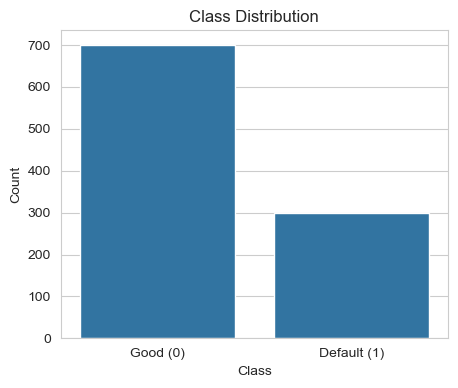

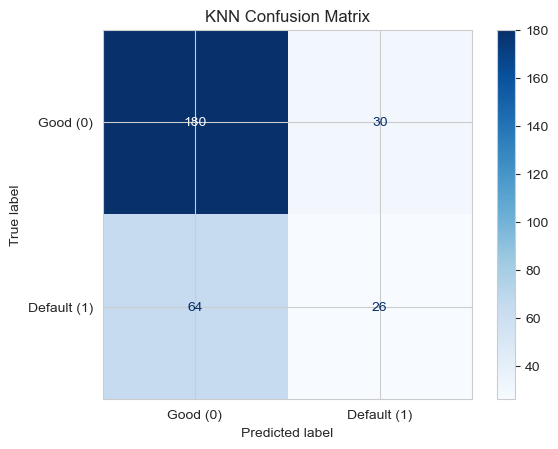

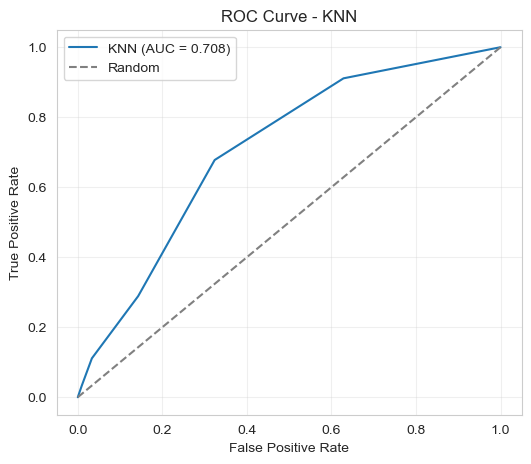

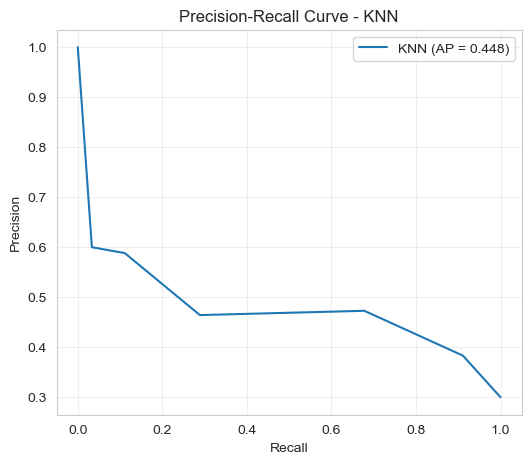

In [8]:
# 4) DIAGRAMS AND VISUAL EVALUATION

# 4.1 Class distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=y_binary)
plt.xticks([0, 1], ["Good (0)", "Default (1)"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 4.2 Confusion matrix heatmap
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Good (0)", "Default (1)"],
    cmap="Blues",
    values_format="d",
)
plt.title("KNN Confusion Matrix")
plt.show()

# 4.3 ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4.4 Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"KNN (AP = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - KNN")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5) Interpretation Notes for Report

- In credit-risk tasks, **recall for default class** and **F1-score** are often more important than accuracy alone.
- The dataset includes a cost matrix where misclassifying a bad customer as good is more expensive.
- Therefore, mention the business trade-off between false positives and false negatives in your report.
- You can also compare baseline and tuned KNN to discuss accuracy-vs-recall trade-offs.

In [10]:
# 6) HYPERPARAMETER TUNING (OPTIONAL, BUT RECOMMENDED)

param_grid = {
    "knn__n_neighbors": np.arange(1, 31, 2),
    "knn__weights": ["uniform", "distance"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    knn_pipe,
    param_grid,
    cv=cv,
    scoring="f1",  # focus on default-class quality
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1 (default):", round(grid.best_score_, 4))

y_pred_tuned = grid.predict(X_test)
y_prob_tuned = grid.predict_proba(X_test)[:, 1]

print("\n=== TUNED KNN TEST RESULTS ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print("Precision (default=1):", round(precision_score(y_test, y_pred_tuned, pos_label=1), 4))
print("Recall (default=1):", round(recall_score(y_test, y_pred_tuned, pos_label=1), 4))
print("F1 (default=1):", round(f1_score(y_test, y_pred_tuned, pos_label=1), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_tuned), 4))

Best params: {'knn__n_neighbors': np.int64(1), 'knn__weights': 'uniform'}
Best CV F1 (default): 0.4455

=== TUNED KNN TEST RESULTS ===
Accuracy: 0.67
Precision (default=1): 0.4526
Recall (default=1): 0.4778
F1 (default=1): 0.4649
ROC-AUC: 0.6151
